# Block 7 — SOLUTION: Evaluating Models — Threshold Adjustment & Class Imbalance
### Advanced Machine Learning — M&T Bank

Loads `bank_marketing_features.csv` (unchanged since Block 3). Same feature prep and train/test split as Blocks
4-6. No new CSV comes out of this lab either.

**Where Block 6 left off:** at the default 0.5 threshold, our logistic regression catches only 20.5% of clients
who'd actually subscribe (recall), while being right 68.1% of the time when it does flag someone (precision).

**Part 1 — Threshold adjustment:** the 0.5 cutoff isn't a law of nature — it's a default. Sweep it and see what
opens up.

**Part 2 — Class imbalance via `class_weight`:** a second lever that changes *training* instead of the decision
rule after the fact. Compare it head-to-head with threshold tuning.

**Part 3 — A fair-lending-style check:** any lever that changes who gets flagged is worth checking for who it
changes it *for*. Age is an ECOA-protected basis — we check flag rates across our own `age` column as a live
example of the technique.


## Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score,
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Paste the raw GitHub URL for bank_marketing_features.csv below, then remove the leading '#':
# df = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";")
print(df.shape)
df.head()


In [2]:
# Same prep and split as Blocks 4-6, for numeric continuity
feature_cols = [c for c in df.columns if c not in ("education", "y", "duration")]
bool_cols = [c for c in df[feature_cols].columns if df[c].dtype == bool]

numeric_to_scale = [
    "age", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "education_rank", "month_sin", "month_cos", "campaign_intensity",
    "emp.var.rate_denoised", "cons.price.idx_denoised", "cons.conf.idx_denoised",
    "euribor3m_denoised", "nr.employed_denoised",
]

X = df[feature_cols].copy()
for c in bool_cols:
    X[c] = X[c].astype(int)
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test_s[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

baseline = LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)
baseline.fit(X_train_s, y_train)
proba = baseline.predict_proba(X_test_s)[:, 1]

print("Baseline @ default 0.5 threshold:")
pred_default = (proba >= 0.5).astype(int)
print(f"  precision={precision_score(y_test, pred_default):.3f}  "
      f"recall={recall_score(y_test, pred_default):.3f}  "
      f"f1={f1_score(y_test, pred_default):.3f}")


Baseline @ default 0.5 threshold:
  precision=0.681  recall=0.205  f1=0.315


# Part 1 — Threshold Adjustment

### Task 1.1 — Sweep the threshold

`predict()` defaults to flagging a client whenever `predict_proba >= 0.5`. That 0.5 is just a default — nothing
about the model requires it. Sweep a range of thresholds and recompute precision, recall, and F1 at each.

**Hint:** `np.arange(0.05, 0.96, 0.05)`, and for each threshold `t`, `(proba >= t).astype(int)`.


In [3]:
thresholds = np.arange(0.05, 0.96, 0.05)
sweep_rows = []
for t in thresholds:
    pred_t = (proba >= t).astype(int)
    sweep_rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
        "n_flagged": int(pred_t.sum()),
    })
sweep = pd.DataFrame(sweep_rows)
sweep.round(3)


,threshold,precision,recall,f1,n_flagged
0,0.05,0.159,0.869,0.269,5074
1,0.10,0.283,0.703,0.404,2301
2,0.15,0.393,0.620,0.481,1464
3,0.20,0.468,0.531,0.498,1053
4,0.25,0.490,0.459,0.474,870
5,0.30,0.523,0.426,0.469,755
6,0.35,0.573,0.370,0.449,599
7,0.40,0.620,0.315,0.417,471
8,0.45,0.637,0.261,0.370,380
9,0.50,0.681,0.205,0.315,279


### Task 1.2 — Plot precision and recall against threshold

**Hint:** two lines on one axis, `sweep["threshold"]` on the x-axis.


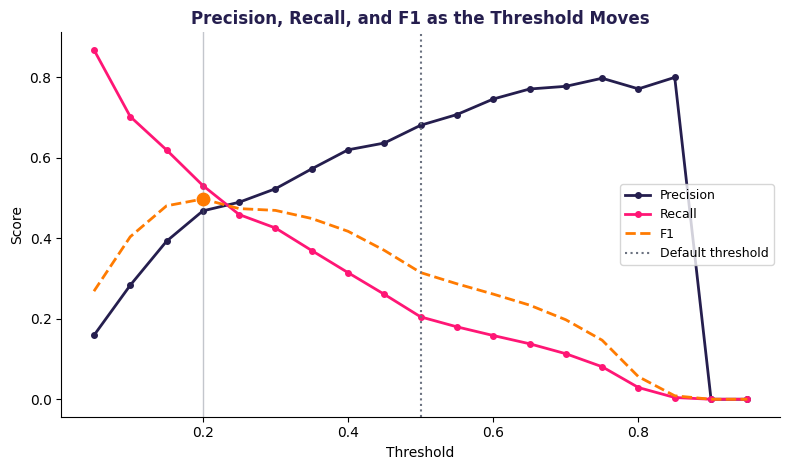

F1-maximizing threshold: 0.20  (F1=0.498, vs. 0.315 at the default 0.5)


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(sweep["threshold"], sweep["precision"], color=NAVY, linewidth=2, marker="o", markersize=4, label="Precision")
ax.plot(sweep["threshold"], sweep["recall"], color=PINK, linewidth=2, marker="o", markersize=4, label="Recall")
ax.plot(sweep["threshold"], sweep["f1"], color=ORANGE, linewidth=2, linestyle="--", label="F1")
ax.axvline(0.5, color=GRAY, linestyle=":", linewidth=1.5, label="Default threshold")

best_idx = sweep["f1"].idxmax()
best_t = sweep.loc[best_idx, "threshold"]
ax.axvline(best_t, color=GRAY, linestyle="-", linewidth=1, alpha=0.4)
ax.scatter([best_t], [sweep.loc[best_idx, "f1"]], color=ORANGE, s=80, zorder=5)

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall, and F1 as the Threshold Moves", color=NAVY, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"F1-maximizing threshold: {best_t:.2f}  (F1={sweep.loc[best_idx, 'f1']:.3f}, "
      f"vs. {f1_score(y_test, pred_default):.3f} at the default 0.5)")


### Task 1.3 — Compare confusion matrices: default vs. tuned threshold

**Hint:** `confusion_matrix(y_test, (proba >= best_t).astype(int))`.


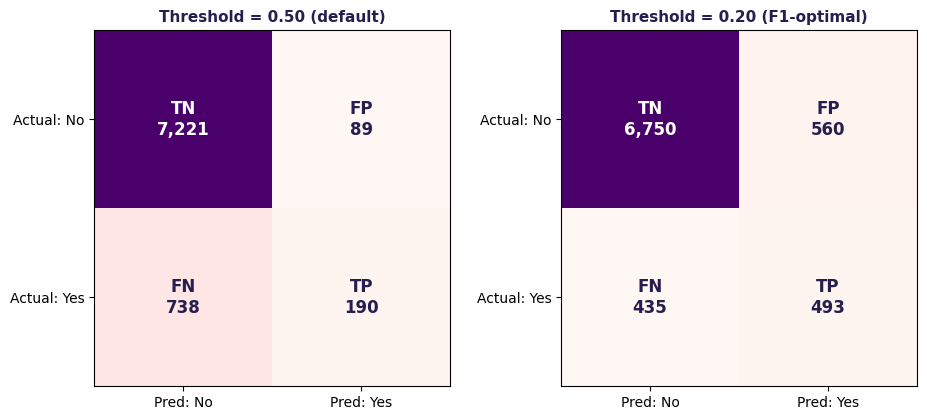

In [5]:
pred_tuned = (proba >= best_t).astype(int)
cm_default = confusion_matrix(y_test, pred_default)
cm_tuned = confusion_matrix(y_test, pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.3))
for ax, cm, title in zip(axes, [cm_default, cm_tuned], [f"Threshold = 0.50 (default)", f"Threshold = {best_t:.2f} (F1-optimal)"]):
    im = ax.imshow(cm, cmap="RdPu")
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]:,}", ha="center", va="center",
                    fontsize=12, color="white" if cm[i, j] > cm.max() / 2 else NAVY, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: No", "Pred: Yes"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: No", "Actual: Yes"])
    ax.set_title(title, color=NAVY, fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()


**Talking point:** moving the threshold from 0.50 down to roughly 0.20 more than doubles recall — we're now
catching about half of the clients who'd actually subscribe, instead of 1 in 5 — at the cost of more false
positives (more wasted calls to clients who say no). Nothing was retrained; this is a completely free lever, and
exactly the kind of tuning that can happen post-deployment without touching the model itself. Whether this new
trade-off point is the *right* one is a business question — it depends on what a wasted call costs versus what a
missed subscriber costs — not something the model can answer on its own.


# Part 2 — Class Imbalance via `class_weight`

### Task 2.1 — Refit with `class_weight="balanced"`

A different lever: instead of moving the decision boundary after training, change what the *training* process
penalizes. `class_weight="balanced"` makes mistakes on the minority class ("yes") cost proportionally more during
fitting, so the model itself shifts toward catching more of them.

**Hint:** same `LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)`, add `class_weight="balanced"`.


In [6]:
balanced_model = LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5, class_weight="balanced")
balanced_model.fit(X_train_s, y_train)
proba_balanced = balanced_model.predict_proba(X_test_s)[:, 1]
pred_balanced = balanced_model.predict(X_test_s)  # still uses 0.5 internally

print("Balanced model @ default 0.5 threshold:")
print(f"  precision={precision_score(y_test, pred_balanced):.3f}  "
      f"recall={recall_score(y_test, pred_balanced):.3f}  "
      f"f1={f1_score(y_test, pred_balanced):.3f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, proba_balanced):.4f}  "
      f"(baseline was {roc_auc_score(y_test, proba):.4f})")


Balanced model @ default 0.5 threshold:
  precision=0.316  recall=0.682  f1=0.432
  ROC-AUC: 0.7964  (baseline was 0.7958)


### Task 2.2 — Three-way comparison

Put all three side by side: the untouched baseline, the class-weighted model (still at 0.5), and the baseline with
its threshold tuned instead.


In [7]:
comparison = pd.DataFrame({
    "Approach": ["Baseline @ 0.50", "class_weight=balanced @ 0.50", f"Baseline @ tuned {best_t:.2f}"],
    "Precision": [
        precision_score(y_test, pred_default),
        precision_score(y_test, pred_balanced),
        precision_score(y_test, pred_tuned),
    ],
    "Recall": [
        recall_score(y_test, pred_default),
        recall_score(y_test, pred_balanced),
        recall_score(y_test, pred_tuned),
    ],
    "F1": [
        f1_score(y_test, pred_default),
        f1_score(y_test, pred_balanced),
        f1_score(y_test, pred_tuned),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, proba),
        roc_auc_score(y_test, proba_balanced),
        roc_auc_score(y_test, proba),
    ],
}).round(4)
comparison


,Approach,Precision,Recall,F1,ROC-AUC
0,Baseline @ 0.50,0.6810,0.2047,0.3148,0.7958
1,class_weight=balanced @ 0.50,0.3162,0.6821,0.4321,0.7964
2,Baseline @ tuned 0.20,0.4682,0.5312,0.4977,0.7958


**Two things worth noticing:**
1. **ROC-AUC barely moves across all three** (0.7958-0.7964) — that's expected. AUC measures the model's ability
   to *rank* clients correctly, and neither reweighting the training loss nor moving the decision threshold changes
   the ranking, only where you choose to cut it.
2. **Simple threshold tuning actually wins on F1 here** (0.498 vs. 0.432 for class-weighting) — a free, post-hoc
   adjustment outperformed retraining the model with a different objective. That's not a universal rule — it won't
   always go this way — but it's a useful reminder not to assume the more complex-sounding technique automatically
   wins. Check both.


# Part 3 — A Fair-Lending-Style Check

**Important framing:** this dataset is a term-deposit *marketing* model, not a credit or lending decision, so ECOA
doesn't directly apply to it. But the analytical technique — checking whether a model's selection rate differs
sharply across a protected class, using a screen like the "four-fifths rule" — is exactly what would be applied to
an actual credit, pricing, or underwriting model, and age is one of ECOA's enumerated protected bases. This is a
live rehearsal of that check, not a real regulatory finding about this dataset.

### Task 3.1 — Flag rate by age band, at two thresholds


In [8]:
age_bins = [17, 25, 35, 45, 55, 65, 98]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
age_band_test = pd.cut(X_test["age"], bins=age_bins, labels=age_labels, include_lowest=True)

flag_rates = pd.DataFrame({
    "Default (0.50)": pd.Series(pred_default, index=X_test.index).groupby(age_band_test, observed=True).mean() * 100,
    f"Tuned ({best_t:.2f})": pd.Series(pred_tuned, index=X_test.index).groupby(age_band_test, observed=True).mean() * 100,
}).round(1)
flag_rates


,Default (0.50),Tuned (0.20)
age,,
18-25,10.9,37.8
26-35,2.7,12.0
36-45,1.5,7.1
46-55,1.8,8.4
56-65,7.3,22.8
66+,41.1,92.2


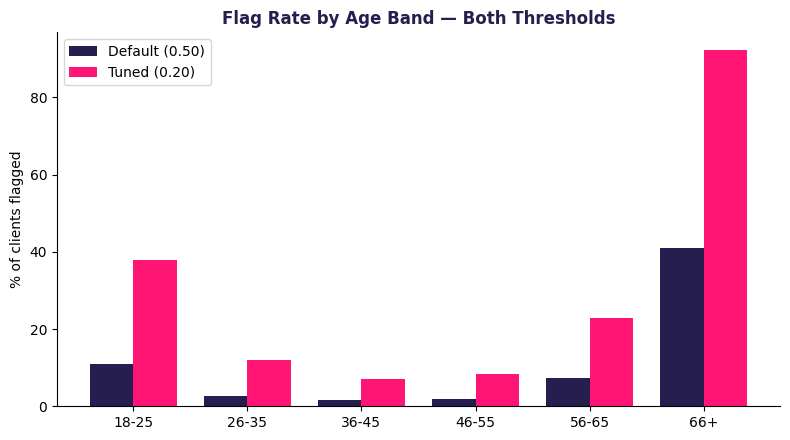

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(flag_rates))
width = 0.38
ax.bar(x - width/2, flag_rates["Default (0.50)"], width, label="Default (0.50)", color=NAVY)
ax.bar(x + width/2, flag_rates[f"Tuned ({best_t:.2f})"], width, label=f"Tuned ({best_t:.2f})", color=PINK)
ax.set_xticks(x)
ax.set_xticklabels(flag_rates.index)
ax.set_ylabel("% of clients flagged")
ax.set_title("Flag Rate by Age Band — Both Thresholds", color=NAVY, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### Task 3.2 — The four-fifths rule

A common screening heuristic: if the lowest-flagged group's rate is under 80% of the highest-flagged group's rate,
that's a signal worth investigating further (not, by itself, proof of unlawful discrimination — legitimate business
justification and less-discriminatory-alternative analysis come next in a real review).

**Hint:** `flag_rates.min() / flag_rates.max()` for each column.


In [10]:
fourfifths = (flag_rates.min() / flag_rates.max()).round(3)
print("Min/max flag-rate ratio by threshold (0.80 = the common four-fifths screening line):")
print(fourfifths)


Min/max flag-rate ratio by threshold (0.80 = the common four-fifths screening line):
Default (0.50)    0.036
Tuned (0.20)      0.077
dtype: float64


**What this actually shows:** the 66+ age band gets flagged at roughly 40x the rate of the 36-45 band at the
default threshold, and both thresholds fail the four-fifths screen by an order of magnitude (ratios of 0.04 and
0.08, versus the 0.80 line). **Tuning the threshold barely moved the ratio** — it changed the *overall* flag rate a
lot, but the *relative* gap between age groups stayed roughly as extreme. That's an important, generalizable
finding: threshold adjustment is not a fairness fix. It can shift how many people get flagged; it does very little
to change the underlying, feature-driven separation between groups that's causing the disparity in the first place.
A real fix — if this were a credit model and the disparity weren't justified by legitimate, non-discriminatory
factors — would mean revisiting the features and the model itself, not the cutoff.

**Also worth naming honestly:** age plausibly drives real, legitimate differences in term-deposit interest (e.g.,
retirees seeking stable income) — the kind of relationship a business-necessity defense would lean on in an actual
credit context. The point of this exercise isn't to conclude this model is unlawful; it's to show *how* you'd run
the check, and that a passing model doesn't happen by accident.


## Recap

- The 0.5 classification threshold is a convention, not a requirement — sweeping it and picking a point on the
  precision/recall trade-off is a free, post-hoc lever that doesn't require retraining.
- `class_weight="balanced"` changes the training objective instead; it moved recall up here too, but actually
  underperformed simple threshold tuning on F1 — worth testing both rather than assuming either wins by default.
- ROC-AUC stayed essentially flat across every variant in this block, because none of these techniques change how
  well the model *ranks* clients — only where you choose to draw the line.
- Any lever that changes who gets flagged is worth checking for who it changes it *for*. The four-fifths screen
  here failed badly regardless of threshold — and moving the threshold didn't meaningfully close that gap, because
  it doesn't touch the feature-driven separation causing it.
- No new CSV from this block — `bank_marketing_features.csv` carries forward unchanged.

**Up next — Block 8:** Evaluating Models — Advanced Metrics + Day 1 Tie-Together.
